In [1]:
import warnings

In [2]:
warnings.filterwarnings("ignore")

In [3]:
import pandas as pd

In [4]:
from sklearn.model_selection import train_test_split

In [5]:
pima_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

In [6]:
pima_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

In [7]:
pima_df = pd.read_csv(pima_url, header=None, names=pima_cols)

In [8]:
X_pima = pima_df[pima_cols[:-1]]

In [9]:
y_pima = pima_df['Outcome']

In [10]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_pima, y_pima, test_size=0.20, stratify=y_pima, random_state=42
)

In [11]:
print("Pima Classification Training Set Shape:", X_train_c.shape)
print("Pima Classification Test Set Shape:", X_test_c.shape)


Pima Classification Training Set Shape: (614, 8)
Pima Classification Test Set Shape: (154, 8)


In [12]:
from sklearn.tree import DecisionTreeClassifier

In [13]:
from sklearn.metrics import accuracy_score, classification_report

In [14]:
tree_clf = DecisionTreeClassifier(max_depth=4, random_state=42)

In [15]:
tree_clf.fit(X_train_c, y_train_c)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [16]:
clf_preds = tree_clf.predict(X_test_c)


In [17]:
print(f"Decision Tree Classifier Test Accuracy: {accuracy_score(y_test_c, clf_preds) * 100:.2f}%\n")

Decision Tree Classifier Test Accuracy: 79.87%



In [26]:
print(classification_report(y_test_c, clf_preds, target_names=['No Diabetes (0)', 'Diabetes (1)']))

                 precision    recall  f1-score   support

No Diabetes (0)       0.82      0.88      0.85       100
   Diabetes (1)       0.74      0.65      0.69        54

       accuracy                           0.80       154
      macro avg       0.78      0.76      0.77       154
   weighted avg       0.80      0.80      0.80       154



In [27]:
import matplotlib.pyplot as plt

In [28]:
from sklearn.tree import plot_tree

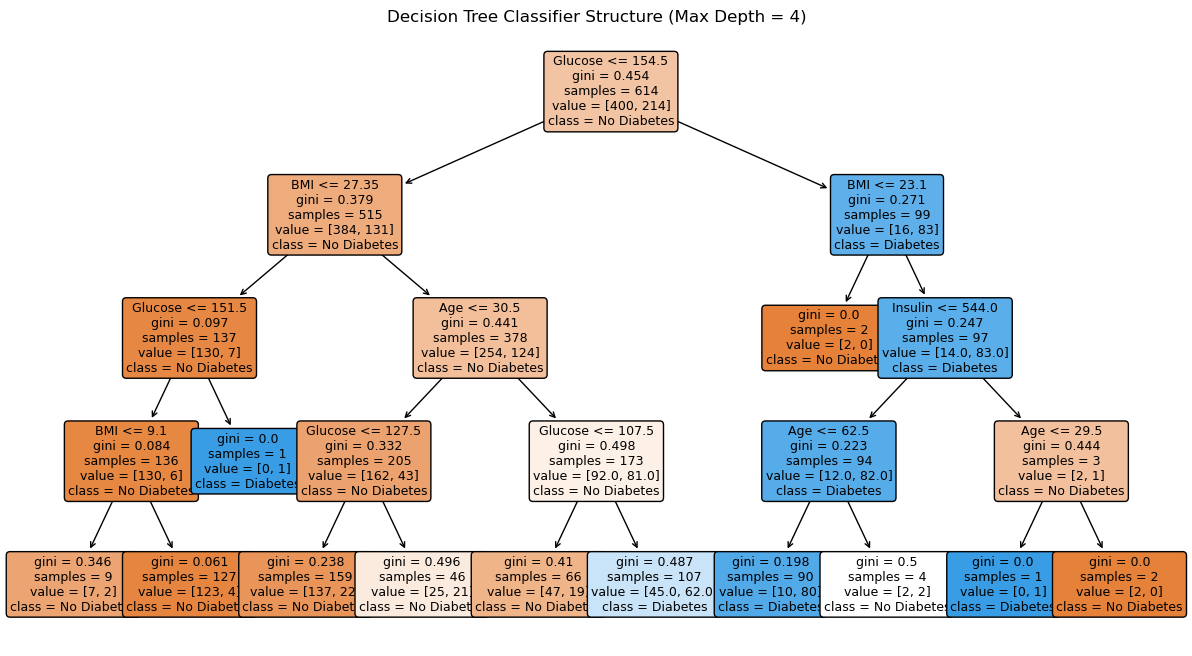

In [34]:
plt.figure(figsize=(15, 8))
plot_tree(
    tree_clf, 
    feature_names=pima_cols[:-1], 
    class_names=['No Diabetes', 'Diabetes'], 
    filled=True, 
    rounded=True, 
    fontsize=9
)
plt.title("Decision Tree Classifier Structure (Max Depth = 4)")
plt.show()

In [35]:
from sklearn.tree import DecisionTreeRegressor

In [36]:
from sklearn.preprocessing import StandardScaler

In [37]:
boston_url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"

In [38]:
boston_df = pd.read_csv(boston_url)

In [39]:
boston_features = [col for col in boston_df.columns if col != 'medv']

In [40]:
X_boston = boston_df[boston_features]

In [41]:
y_boston = boston_df['medv']


In [42]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_boston, y_boston, test_size=0.20, random_state=42)

In [43]:
scaler_r = StandardScaler()

In [44]:
X_train_r_scaled = scaler_r.fit_transform(X_train_r)

In [45]:
X_test_r_scaled = scaler_r.transform(X_test_r)

In [46]:
tree_reg = DecisionTreeRegressor(max_depth=5, random_state=42)
tree_reg.fit(X_train_r_scaled, y_train_r)

DecisionTreeRegressor(max_depth=5, random_state=42)

In [47]:
print("Decision Tree Regressor trained successfully. Max Depth set to 5.")

Decision Tree Regressor trained successfully. Max Depth set to 5.


In [48]:
from sklearn.metrics import mean_squared_error, r2_score

In [49]:
import numpy as np

In [50]:
reg_preds = tree_reg.predict(X_test_r_scaled)

In [51]:
mse_val = mean_squared_error(y_test_r, reg_preds)

In [52]:
rmse_val = np.sqrt(mse_val)

In [53]:
r2_val = r2_score(y_test_r, reg_preds)

In [54]:
print(f"Mean Squared Error (MSE): {mse_val:.4f}")

Mean Squared Error (MSE): 8.5539


In [55]:
print(f"Root Mean Squared Error (RMSE): {rmse_val:.4f} ($1000s)")

Root Mean Squared Error (RMSE): 2.9247 ($1000s)


In [56]:
print(f"R2 Coefficient of Determination: {r2_val:.4f}\n")

R2 Coefficient of Determination: 0.8834



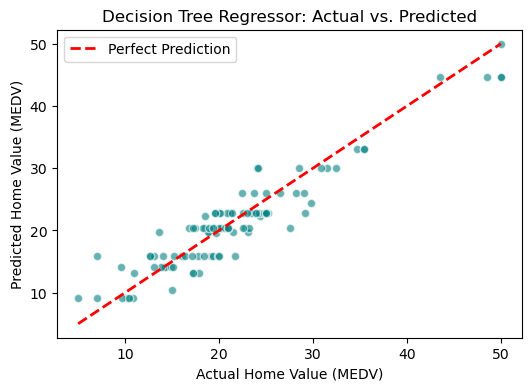

In [57]:
plt.figure(figsize=(6, 4))
plt.scatter(y_test_r, reg_preds, color='teal', alpha=0.6, edgecolor='white')
plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title("Decision Tree Regressor: Actual vs. Predicted")
plt.xlabel("Actual Home Value (MEDV)")
plt.ylabel("Predicted Home Value (MEDV)")
plt.legend()
plt.show()


In [58]:
import warnings

In [59]:
warnings.filterwarnings("ignore")

In [60]:
import pandas as pd

In [61]:
from sklearn.model_selection import train_test_split

In [62]:
from sklearn.preprocessing import StandardScaler

In [63]:
sonar_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/sonar.csv"

In [64]:
sonar_features = [f"F_{i}" for i in range(1, 61)]

In [65]:
sonar_columns = sonar_features + ['Class']

In [66]:
sonar_df = pd.read_csv(sonar_url, header=None, names=sonar_columns)

In [67]:
sonar_df['Class_numeric'] = sonar_df['Class'].map({'M': 1, 'R': 0})

In [68]:
X_sonar = sonar_df[sonar_features]

In [69]:
y_sonar = sonar_df['Class_numeric']

In [70]:
scaler_sonar = StandardScaler()

In [71]:
X_sonar_scaled = scaler_sonar.fit_transform(X_sonar)

In [72]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sonar_scaled, y_sonar, test_size=0.30, stratify=y_sonar, random_state=42
)


In [73]:
print("Sonar Training Set Shape:", X_train_s.shape)
print("Sonar Test Set Shape:", X_test_s.shape)

Sonar Training Set Shape: (145, 60)
Sonar Test Set Shape: (63, 60)


In [74]:
from sklearn.ensemble import BaggingClassifier

In [75]:
from sklearn.metrics import accuracy_score

In [76]:
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

In [77]:
bagging_model.fit(X_train_s, y_train_s)

BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                  n_estimators=50, n_jobs=-1, random_state=42)

In [78]:
bagging_preds = bagging_model.predict(X_test_s)

In [79]:
bagging_accuracy = accuracy_score(y_test_s, bagging_preds)


In [80]:
print(f"Bagging Classifier Test Accuracy: {bagging_accuracy * 100:.2f}%")

Bagging Classifier Test Accuracy: 80.95%


In [81]:
from sklearn.ensemble import RandomForestClassifier

In [82]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

In [83]:
rf_model.fit(X_train_s, y_train_s)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [84]:
rf_preds = rf_model.predict(X_test_s)

In [85]:
rf_accuracy = accuracy_score(y_test_s, rf_preds)

In [86]:
print(f"Random Forest Classifier Test Accuracy: {rf_accuracy * 100:.2f}%")

Random Forest Classifier Test Accuracy: 82.54%


In [87]:
from sklearn.ensemble import VotingClassifier

In [88]:
from sklearn.linear_model import LogisticRegression

In [89]:
from sklearn.svm import SVC

In [90]:
estimators = [
    ('lr', LogisticRegression(max_iter=500, random_state=42)),
    ('dt', DecisionTreeClassifier(max_depth=5, random_state=42)),
    ('svc', SVC(probability=True, random_state=42))
]

In [91]:
voting_model = VotingClassifier(estimators=estimators, voting='soft', n_jobs=-1)

In [92]:
voting_model.fit(X_train_s, y_train_s)

VotingClassifier(estimators=[('lr',
                              LogisticRegression(max_iter=500,
                                                 random_state=42)),
                             ('dt',
                              DecisionTreeClassifier(max_depth=5,
                                                     random_state=42)),
                             ('svc', SVC(probability=True, random_state=42))],
                 n_jobs=-1, voting='soft')

In [93]:
voting_preds = voting_model.predict(X_test_s)

In [94]:
voting_accuracy = accuracy_score(y_test_s, voting_preds)

In [95]:
print(f"Voting Classifier Test Accuracy: {voting_accuracy * 100:.2f}%")

Voting Classifier Test Accuracy: 87.30%


In [96]:
import matplotlib.pyplot as plt

In [97]:
import seaborn as sns

In [98]:
ensemble_results = pd.DataFrame({
    'Ensemble Technique': ['Bagging (DT Base)', 'Random Forest', 'Voting Classifier (Soft)'],
    'Test Accuracy (%)': [bagging_accuracy * 100, rf_accuracy * 100, voting_accuracy * 100]
})

In [99]:
print("--- Performance Comparison ---")
print(ensemble_results.to_string(index=False))

--- Performance Comparison ---
      Ensemble Technique  Test Accuracy (%)
       Bagging (DT Base)          80.952381
           Random Forest          82.539683
Voting Classifier (Soft)          87.301587


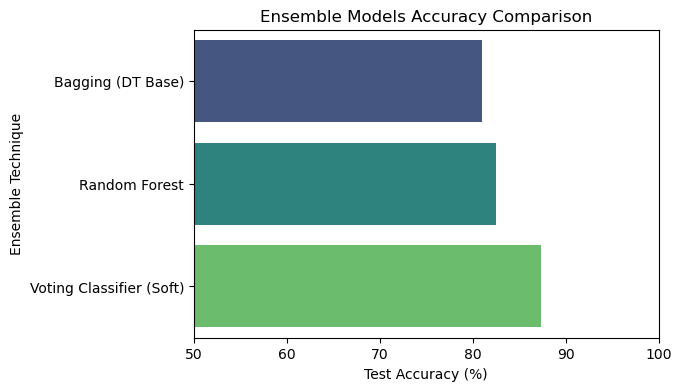

In [100]:
plt.figure(figsize=(6, 4))
sns.barplot(data=ensemble_results, x='Test Accuracy (%)', y='Ensemble Technique', palette='viridis')
plt.xlim([50, 100])
plt.title("Ensemble Models Accuracy Comparison")
plt.show()

In [101]:
import warnings


In [102]:
warnings.filterwarnings("ignore")


In [103]:
from sklearn.ensemble import AdaBoostClassifier

In [104]:
from sklearn.metrics import accuracy_score

In [105]:
adaboost_model = AdaBoostClassifier(n_estimators=50, random_state=42)

In [106]:
adaboost_model.fit(X_train_s, y_train_s)

AdaBoostClassifier(random_state=42)

In [107]:
ada_preds = adaboost_model.predict(X_test_s)

In [108]:
ada_accuracy = accuracy_score(y_test_s, ada_preds)

In [109]:
print(f"AdaBoost Classifier Test Accuracy: {ada_accuracy * 100:.2f}%")

AdaBoost Classifier Test Accuracy: 82.54%


In [110]:
from sklearn.ensemble import GradientBoostingClassifier

In [111]:
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)

In [112]:
gb_model.fit(X_train_s, y_train_s)

GradientBoostingClassifier(random_state=42)

In [113]:
gb_preds = gb_model.predict(X_test_s)

In [114]:
gb_accuracy = accuracy_score(y_test_s, gb_preds)

In [115]:
print(f"Gradient Boosting Classifier Test Accuracy: {gb_accuracy * 100:.2f}%")

Gradient Boosting Classifier Test Accuracy: 79.37%


In [116]:
from sklearn.model_selection import GridSearchCV

In [117]:
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 4, 5]
}

In [118]:
grid_gb = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

In [119]:
grid_gb.fit(X_train_s, y_train_s)

GridSearchCV(cv=3, estimator=GradientBoostingClassifier(random_state=42),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [3, 4, 5],
                         'n_estimators': [50, 100, 150]},
             scoring='accuracy')

In [120]:
best_gb = grid_gb.best_estimator_

In [121]:
tuned_gb_preds = best_gb.predict(X_test_s)

In [122]:
tuned_gb_accuracy = accuracy_score(y_test_s, tuned_gb_preds)

In [123]:
print("Optimal Hyperparameters Selected:", grid_search_params := grid_gb.best_params_)
print(f"Tuned Gradient Boosting Test Accuracy: {tuned_gb_accuracy * 100:.2f}%")


Optimal Hyperparameters Selected: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 50}
Tuned Gradient Boosting Test Accuracy: 74.60%


In [125]:
master_comparison = pd.DataFrame({
    'Model Classifier': [
        'Bagging Classifier', 
        'Random Forest Classifier', 
        'Voting Ensemble (Soft)', 
        'AdaBoost Classifier', 
        'Base Gradient Boosting', 
        'Tuned Gradient Boosting'
    ],
    'Accuracy (%)': [
        bagging_accuracy * 100, 
        rf_accuracy * 100, 
        voting_accuracy * 100, 
        ada_accuracy * 100, 
        gb_accuracy * 100, 
        tuned_gb_accuracy * 100
    ]
}).sort_values(by='Accuracy (%)', ascending=False)

In [126]:
print("--- Master Performance Table: Tasks 2 & 3 --z-")
print(master_comparison.to_string(index=False))

--- Master Performance Table: Tasks 2 & 3 --z-
        Model Classifier  Accuracy (%)
  Voting Ensemble (Soft)     87.301587
Random Forest Classifier     82.539683
     AdaBoost Classifier     82.539683
      Bagging Classifier     80.952381
  Base Gradient Boosting     79.365079
 Tuned Gradient Boosting     74.603175


In [127]:
import matplotlib.pyplot as plt


In [128]:
import numpy as np

In [129]:
rf_importances = rf_model.feature_importances_
gb_importances = best_gb.feature_importances_


In [130]:
top_indices_rf = np.argsort(rf_importances)[-10:]
top_indices_gb = np.argsort(gb_importances)[-10:]

In [131]:
features_list = [f"F_{i}" for i in range(1, 61)]

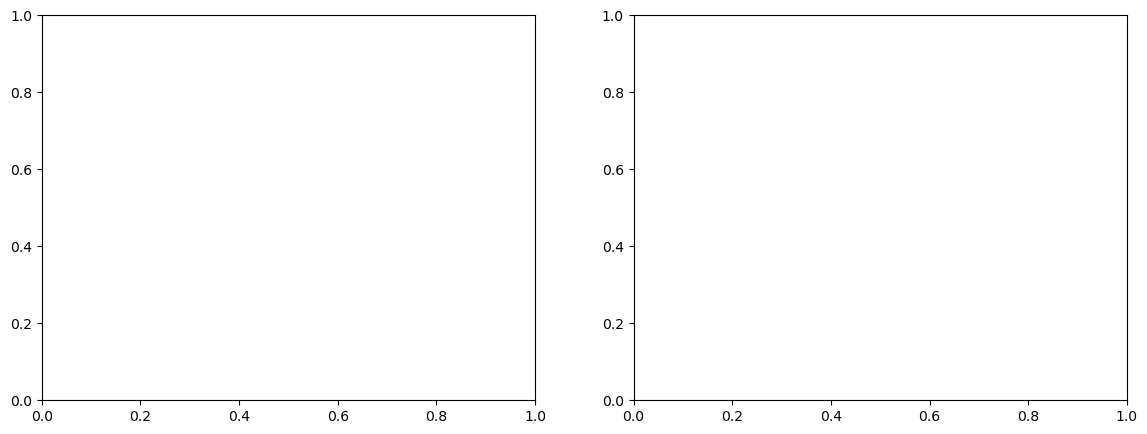

In [132]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

In [133]:
axes[0].barh(range(10), rf_importances[top_indices_rf], color='royalblue', align='center')
axes[0].set_yticks(range(10))
axes[0].set_yticklabels([features_list[i] for i in top_indices_rf])
axes[0].set_title("Top 10 Feature Importances: Random Forest")
axes[0].set_xlabel("Relative Importance")

Text(0.5, 4.444444444444445, 'Relative Importance')

In [134]:
axes[1].set_yticks(range(10))
axes[1].set_yticklabels([features_list[i] for i in top_indices_gb])
axes[1].set_title("Top 10 Feature Importances: Tuned Gradient Boosting")
axes[1].set_xlabel("Relative Importance")


Text(0.5, 4.444444444444445, 'Relative Importance')

In [135]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

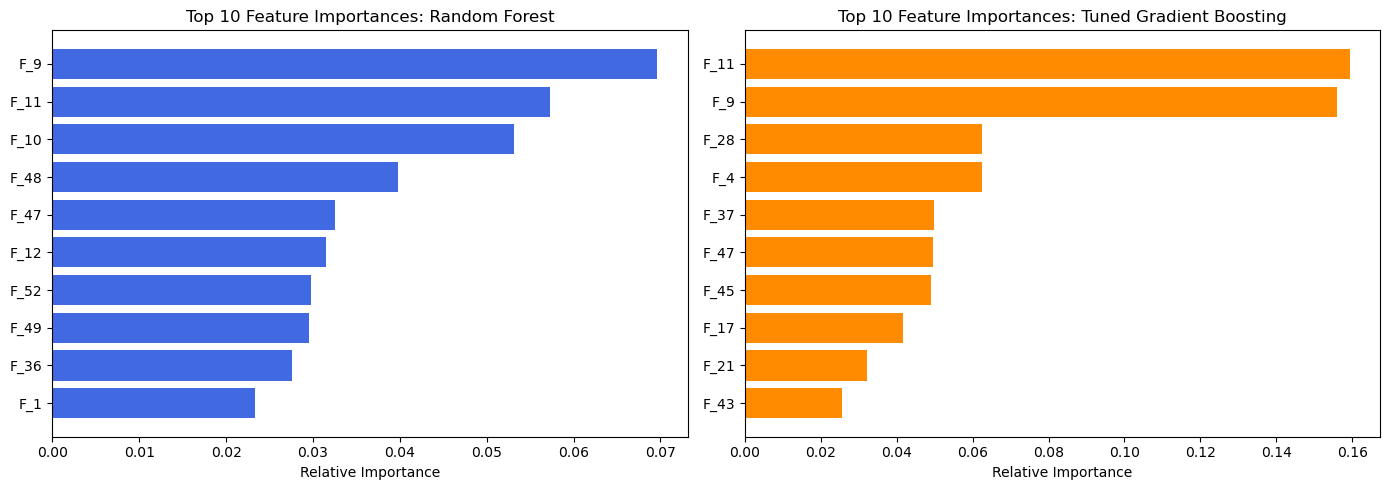

In [139]:
import matplotlib.pyplot as plt
import numpy as np

rf_importances = rf_model.feature_importances_
gb_importances = best_gb.feature_importances_


top_indices_rf = np.argsort(rf_importances)[-10:]
top_indices_gb = np.argsort(gb_importances)[-10:]


features_list = [f"F_{i}" for i in range(1, 61)]


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(range(10), rf_importances[top_indices_rf], color='royalblue', align='center')
axes[0].set_yticks(range(10))
axes[0].set_yticklabels([features_list[i] for i in top_indices_rf])
axes[0].set_title("Top 10 Feature Importances: Random Forest")
axes[0].set_xlabel("Relative Importance")


axes[1].barh(range(10), gb_importances[top_indices_gb], color='darkorange', align='center')
axes[1].set_yticks(range(10))
axes[1].set_yticklabels([features_list[i] for i in top_indices_gb])
axes[1].set_title("Top 10 Feature Importances: Tuned Gradient Boosting")
axes[1].set_xlabel("Relative Importance")

plt.tight_layout()
plt.show()

In [140]:
import pandas as pd

In [141]:
import numpy as np

In [142]:
import matplotlib.pyplot as plt

In [143]:
import seaborn as sns

In [144]:
from sklearn.model_selection import train_test_split

In [145]:
from sklearn.compose import ColumnTransformer

In [146]:
from sklearn.pipeline import Pipeline

In [147]:
from sklearn.impute import SimpleImputer

In [148]:
from sklearn.preprocessing import OneHotEncoder

In [149]:
from sklearn.preprocessing import StandardScaler

In [150]:
from sklearn.linear_model import LogisticRegression

In [151]:
from sklearn.ensemble import RandomForestClassifier

In [152]:
from sklearn.metrics import accuracy_score

In [153]:
from sklearn.metrics import classification_report

In [154]:
from sklearn.metrics import confusion_matrix

In [155]:
from sklearn.metrics import ConfusionMatrixDisplay

In [157]:
df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")

In [158]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [159]:
df.shape

(891, 12)

In [160]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [161]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [162]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [163]:
import pandas as pd

<Axes: xlabel='Survived', ylabel='count'>

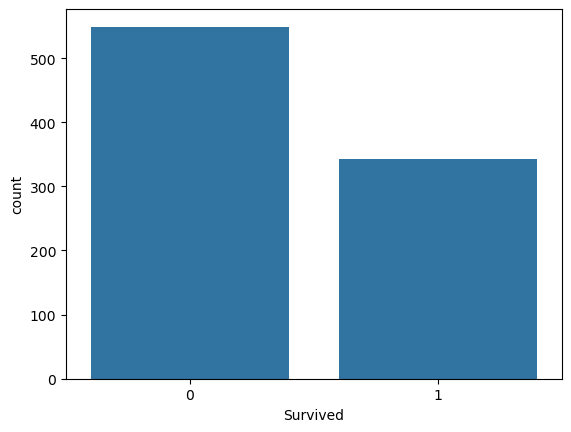

In [164]:
sns.countplot(data=df, x="Survived")

Text(0.5, 1.0, 'Survival Distribution')

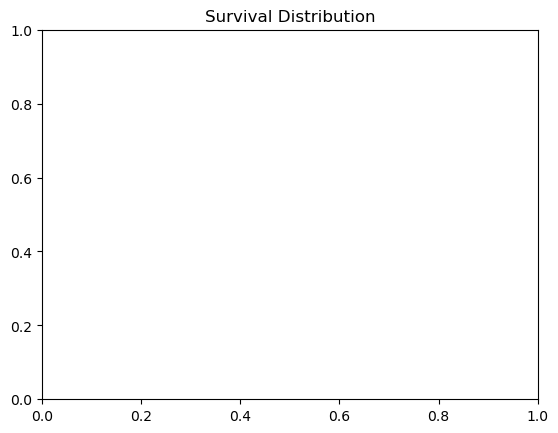

In [165]:
plt.title("Survival Distribution")

In [166]:
plt.show()

<Axes: xlabel='Sex', ylabel='count'>

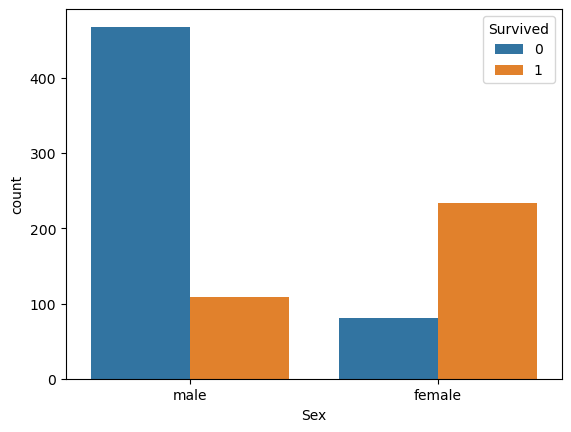

In [167]:
sns.countplot(data=df, x="Sex", hue="Survived")

Text(0.5, 1.0, 'Survival by Gender')

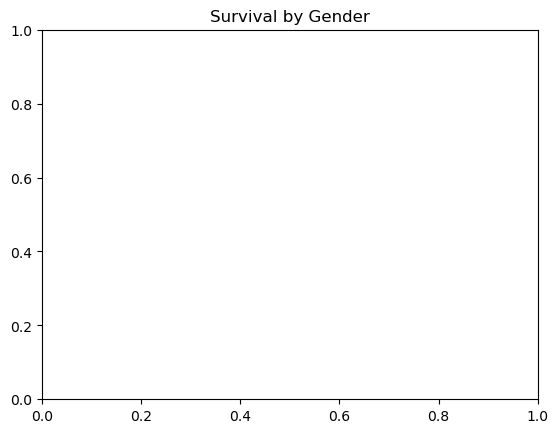

In [168]:
plt.title("Survival by Gender")

In [169]:
plt.show()

<Axes: xlabel='Pclass', ylabel='count'>

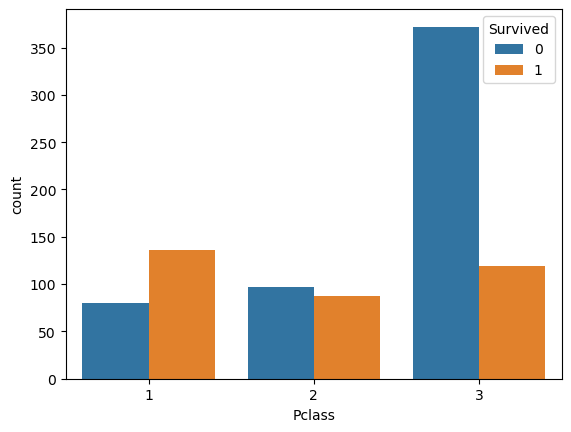

In [170]:
sns.countplot(data=df, x="Pclass", hue="Survived")

Text(0.5, 1.0, 'Survival by Passenger Class')

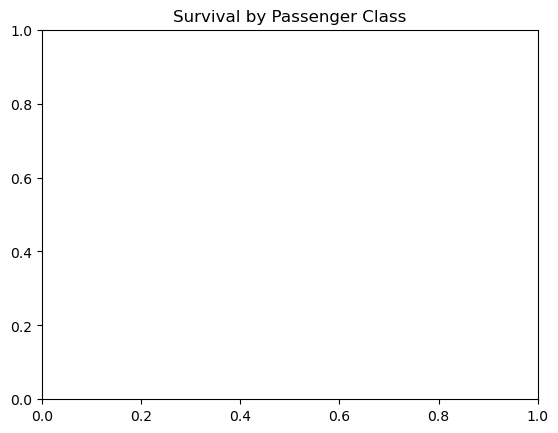

In [171]:
plt.title("Survival by Passenger Class")

In [172]:
plt.show()

In [173]:
features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]

In [174]:
X = df[features]

In [175]:
y = df["Survived"]

In [176]:
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


In [177]:
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

In [178]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

In [179]:
X_train.shape

(712, 7)

In [180]:
numeric_features = ["Pclass", "Age", "SibSp", "Parch", "Fare"]

In [181]:
categorical_features = ["Sex", "Embarked"]

In [182]:
numeric_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])

In [183]:
categorical_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))])

In [184]:
preprocessor = ColumnTransformer(transformers=[("num", numeric_transformer, numeric_features), ("cat", categorical_transformer, categorical_features)])

In [185]:
logistic_model = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", LogisticRegression(max_iter=1000))])


In [186]:
logistic_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Pclass', 'Age', 'SibSp',
                                                   'Parch', 'Fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Sex', 'Embarked'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [187]:
y_pred = logistic_model.predict(X_test)

In [188]:
accuracy_score(y_test, y_pred)

0.8044692737430168

In [189]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



In [190]:
cm = confusion_matrix(y_test, y_pred)

In [191]:
print(cm)

[[98 12]
 [23 46]]


In [192]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Did Not Survive", "Survived"])

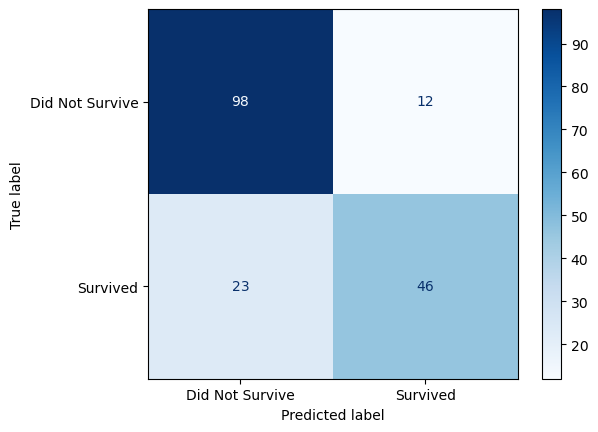

In [193]:
disp.plot(cmap="Blues")

In [194]:
plt.show()

In [195]:
random_forest_model = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", RandomForestClassifier(n_estimators=200, random_state=42))])


In [196]:
random_forest_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Pclass', 'Age', 'SibSp',
                                                   'Parch', 'Fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Sex', 'Embarked'])])),
                ('classifier',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

In [197]:
rf_pred = random_forest_model.predict(X_test)

In [198]:
rf_accuracy = accuracy_score(y_test, rf_pred)

In [199]:
print(rf_accuracy)

0.8156424581005587


In [200]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.82      0.89      0.86       110
           1       0.80      0.70      0.74        69

    accuracy                           0.82       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.81      0.82      0.81       179



In [201]:
rf_cm = confusion_matrix(y_test, rf_pred)

In [202]:
print(rf_cm)

[[98 12]
 [21 48]]


In [203]:
rf_disp = ConfusionMatrixDisplay(confusion_matrix=rf_cm, display_labels=["Did Not Survive", "Survived"])

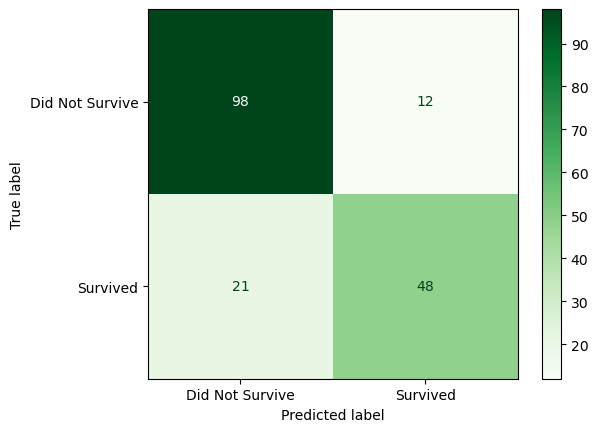

In [204]:
rf_disp.plot(cmap="Greens")

In [205]:
plt.show()

In [206]:
logistic_accuracy = accuracy_score(y_test, y_pred)

In [207]:
results = pd.DataFrame({"Model": ["Logistic Regression", "Random Forest"], "Accuracy": [logistic_accuracy, rf_accuracy]})

In [208]:
results

,Model,Accuracy
0,Logistic Regression,0.804469
1,Random Forest,0.815642


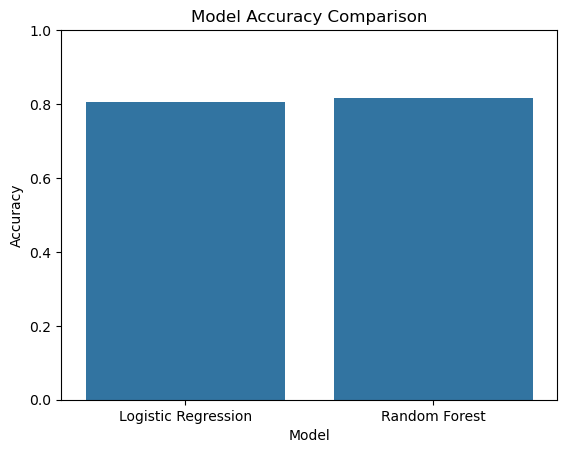

In [209]:
plt.title("Model Accuracy Comparison")
sns.barplot(data=results, x="Model", y="Accuracy")
plt.ylim(0, 1)
plt.show()

In [210]:
rf_classifier = random_forest_model.named_steps["classifier"]

In [211]:
rf_classifier.feature_importances_

array([0.08753432, 0.24234131, 0.04638209, 0.03930078, 0.25399095,
       0.13934458, 0.15513941, 0.01245475, 0.00791707, 0.01559472])

In [212]:
importances = rf_classifier.feature_importances_

In [213]:
len(importances)

10

In [214]:
importances

array([0.08753432, 0.24234131, 0.04638209, 0.03930078, 0.25399095,
       0.13934458, 0.15513941, 0.01245475, 0.00791707, 0.01559472])

In [215]:
feature_names = random_forest_model.named_steps["preprocessor"].get_feature_names_out()

In [216]:
feature_names

array(['num__Pclass', 'num__Age', 'num__SibSp', 'num__Parch', 'num__Fare',
       'cat__Sex_female', 'cat__Sex_male', 'cat__Embarked_C',
       'cat__Embarked_Q', 'cat__Embarked_S'], dtype=object)

In [217]:
importance_df = pd.DataFrame({"Feature": feature_names, "Importance": importances})

In [218]:
importance_df

,Feature,Importance
0,num__Pclass,0.087534
1,num__Age,0.242341
2,num__SibSp,0.046382
3,num__Parch,0.039301
4,num__Fare,0.253991
5,cat__Sex_female,0.139345
6,cat__Sex_male,0.155139
7,cat__Embarked_C,0.012455
8,cat__Embarked_Q,0.007917
9,cat__Embarked_S,0.015595


In [219]:
importance_df = importance_df.sort_values("Importance", ascending=False)

In [220]:
importance_df


,Feature,Importance
4,num__Fare,0.253991
1,num__Age,0.242341
6,cat__Sex_male,0.155139
5,cat__Sex_female,0.139345
0,num__Pclass,0.087534
2,num__SibSp,0.046382
3,num__Parch,0.039301
9,cat__Embarked_S,0.015595
7,cat__Embarked_C,0.012455
8,cat__Embarked_Q,0.007917


<Axes: xlabel='Importance', ylabel='Feature'>

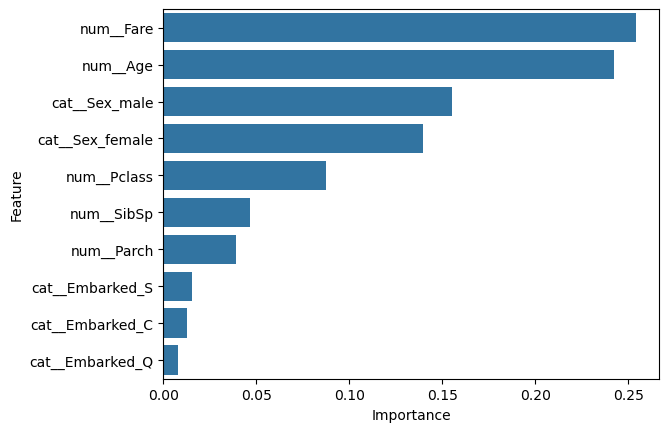

In [221]:
sns.barplot(data=importance_df.head(10), x="Importance", y="Feature")

Text(0.5, 1.0, 'Top 10 Feature Importances')

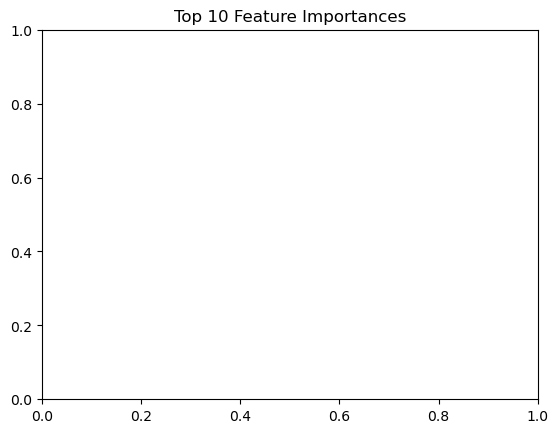

In [222]:
plt.title("Top 10 Feature Importances")

In [223]:
plt.show()

In [224]:
X_test.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
565,3,male,24.0,2,0,24.1500,S
160,3,male,44.0,0,1,16.1000,S
553,3,male,22.0,0,0,7.2250,C
860,3,male,41.0,2,0,14.1083,S
241,3,female,NaN,1,0,15.5000,Q


In [225]:
sample = X_test.iloc[[0]]

In [226]:
sample

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
565,3,male,24.0,2,0,24.15,S


In [227]:
prediction = random_forest_model.predict(sample)

In [228]:
prediction

array([0], dtype=int64)

In [229]:
print("Predicted Survival:", prediction[0])

Predicted Survival: 0


In [230]:
if prediction[0] == 1:
    print("Passenger is predicted to SURVIVE")

In [231]:
if prediction[0] == 0:
    print("Passenger is predicted NOT TO SURVIVE")

Passenger is predicted NOT TO SURVIVE


In [234]:
print("Logistic Regression Accuracy:", logistic_accuracy)
print("Random Forest Accuracy:", rf_accuracy)
if rf_accuracy > logistic_accuracy:
    print("Random Forest performed better.")
if logistic_accuracy > rf_accuracy:
    print("Logistic Regression performed better.")
if logistic_accuracy == rf_accuracy:
    print("Both models have the same accuracy.")
 

Logistic Regression Accuracy: 0.8044692737430168
Random Forest Accuracy: 0.8156424581005587
Random Forest performed better.


In [235]:
print("Titanic Classification Task Completed Successfully!")

Titanic Classification Task Completed Successfully!
